In [7]:
#RQ1: Are there statistically significant effects for streamer gender, age, and genre on the total amount of emotes and 
#the unique number of emotes used in chats?
# total emotes = overdispersed -> Negative binominal
# unique emotes = good dispersion -> Poisson
# both with streamer level clustered SE

In [3]:
import pandas as pd
import statsmodels.formula.api as smf
import io # for latex table)
import matplotlib.pyplot as plt

import numpy as np

In [4]:
df = pd.read_csv("/Users/inecuypers/Documents/DTA thesis/finals/df_sentiment_emotion_final.csv", index_col=0)
df.head(1)

,id,streamer,message,emotes,gender,age,genre,unique_emotes,total_emotes,sentiment,...,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,6b9fd713-82dc-4f76-90b3-a7d2f006e1ac,annacramling,Gg CoolCat,CoolCat,female,genz,nongaming,1,1,2,...,False,False,False,True,False,True,False,False,False,True


In [5]:
# check dispersion
# mean
mean_total = df["total_emotes"].mean()
mean_unique = df["unique_emotes"].mean()

# variance
var_total = df["total_emotes"].var()
var_unique = df["unique_emotes"].var()

print("Total emotes - mean:", mean_total, "variance:", var_total) # overdispersed -> NB
print("Unique emotes - mean:", mean_unique, "variance:", var_unique) # underdisprsed -> P

Total emotes - mean: 2.516770833333333 variance: 12.700208344185159
Unique emotes - mean: 1.1961458333333332 variance: 0.46876314155988474


In [6]:
# Negative Binominal GLM - total and unique emotes (statsmodels)
# If α is significantly greater than zero: 
# It proves that overdispersion exists and your choice of Negative Binomial was mathematically necessary.
# In your Thesis: You should report this α value and its p-value to justify why you didn't use a simpler Poisson model.

model_total = smf.negativebinomial(
    formula="total_emotes ~ gender * age * genre",
    data=df
)
results_total_nb = model_total.fit(cov_type="cluster", cov_kwds={"groups": df["streamer"]})

print(f"Estimated Alpha Total: {results_total_nb.params['alpha']}")
print(results_total_nb.summary())

model_unique = smf.poisson(
    formula="unique_emotes ~ gender * age * genre",
    data=df
)
results_unique_nb = model_unique.fit(cov_type="cluster", cov_kwds={"groups": df["streamer"]})

print(results_unique_nb.summary())

html_string = results_total_nb.summary().tables[1].as_html()
results_df = pd.read_html(io.StringIO(html_string), header=0, index_col=0)[0]
results_df.to_latex("cleaned_coefficients_total.tex", 
                    bold_rows=True, 
                    column_format='lrrrr', # Left align index, right align numbers
                    caption="Negative Binomial Regression Results (Total Emotes)",
                    label="tab:nb_results",
                    escape=False)


html_string = results_unique_nb.summary().tables[1].as_html()
results_df = pd.read_html(io.StringIO(html_string), header=0, index_col=0)[0]
results_df.to_latex("cleaned_coefficients_unique.tex", 
                    bold_rows=True, 
                    column_format='lrrrr', # Left align index, right align numbers
                    caption="Negative Binomial Regression Results (Unique Emotes)",
                    label="tab:nb_results",
                    escape=False)

Optimization terminated successfully.
         Current function value: 2.011068
         Iterations: 5
         Function evaluations: 6
         Gradient evaluations: 6
Estimated Alpha Total: 0.49903504126891474
                     NegativeBinomial Regression Results                      
Dep. Variable:           total_emotes   No. Observations:                 9600
Model:               NegativeBinomial   Df Residuals:                     9592
Method:                           MLE   Df Model:                            7
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.02329
Time:                        18:22:50   Log-Likelihood:                -19306.
converged:                       True   LL-Null:                       -19767.
Covariance Type:              cluster   LLR p-value:                1.677e-194
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

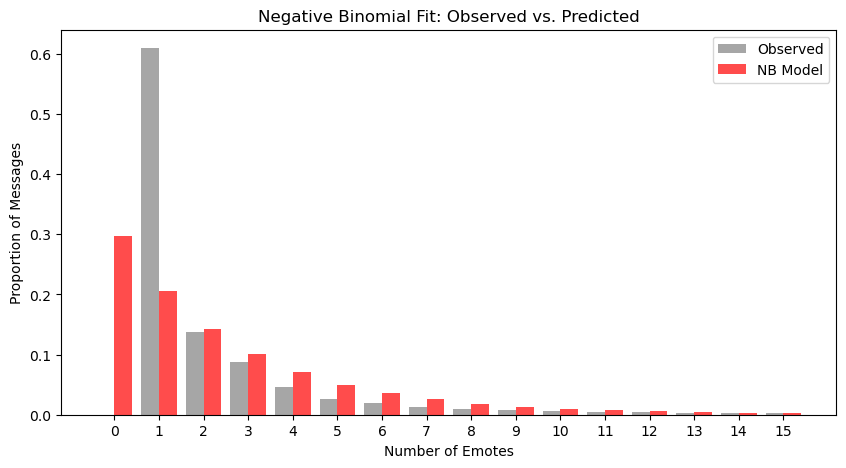

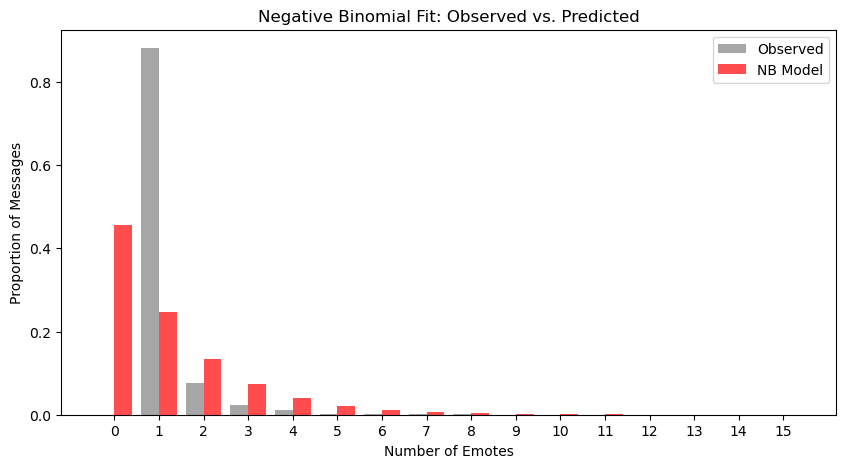

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import nbinom

def plot_frequency_comparison(model_results, y_obs,name, max_draw=15):
    # 1. Get predicted means
    mu = model_results.predict()
    
    # 2. Extract Alpha (Dispersion parameter)
    # For sm.GLM, alpha is often calculated as (pearson_chi2 / df_resid) 
    # or you can use the fixed alpha from the NB family
    alpha = model_results.scale 
    
    # 3. Create a fixed count range
    counts = np.arange(0, max_draw + 1)
    
    # 4. Calculate predicted probabilities 
    # We use axis=0 to ensure we get one mean probability per count across all observations
    expected_probs = np.mean([nbinom.pmf(counts, 1/alpha, 1/(1 + alpha*m)) for m in mu], axis=0)
    
    # 5. Handle the observed data shape mismatch
    # np.bincount only goes up to the max value in y_obs. We pad it with zeros.
    raw_obs_counts = np.bincount(y_obs)
    obs_probs = np.zeros(max_draw + 1)
    
    # Fill only up to the available data or max_draw, whichever is smaller
    limit = min(len(raw_obs_counts), max_draw + 1)
    obs_probs[:limit] = raw_obs_counts[:limit] / len(y_obs)
    
    # 6. Plot
    plt.figure(figsize=(10, 5))
    plt.bar(counts - 0.2, obs_probs, width=0.4, label='Observed', color='gray', alpha=0.7)
    plt.bar(counts + 0.2, expected_probs, width=0.4, label='NB Model', color='red', alpha=0.7)
    
    plt.xticks(counts)
    plt.xlabel('Number of Emotes')
    plt.ylabel('Proportion of Messages')
    plt.title('Negative Binomial Fit: Observed vs. Predicted')
    plt.legend()
    plt.savefig(f'plot_frequency_comparison_{name}.png')
    plt.show()

plot_frequency_comparison(results_total_nb, df['total_emotes'], 'total')
plot_frequency_comparison(results_unique_nb, df['unique_emotes'], 'unique')

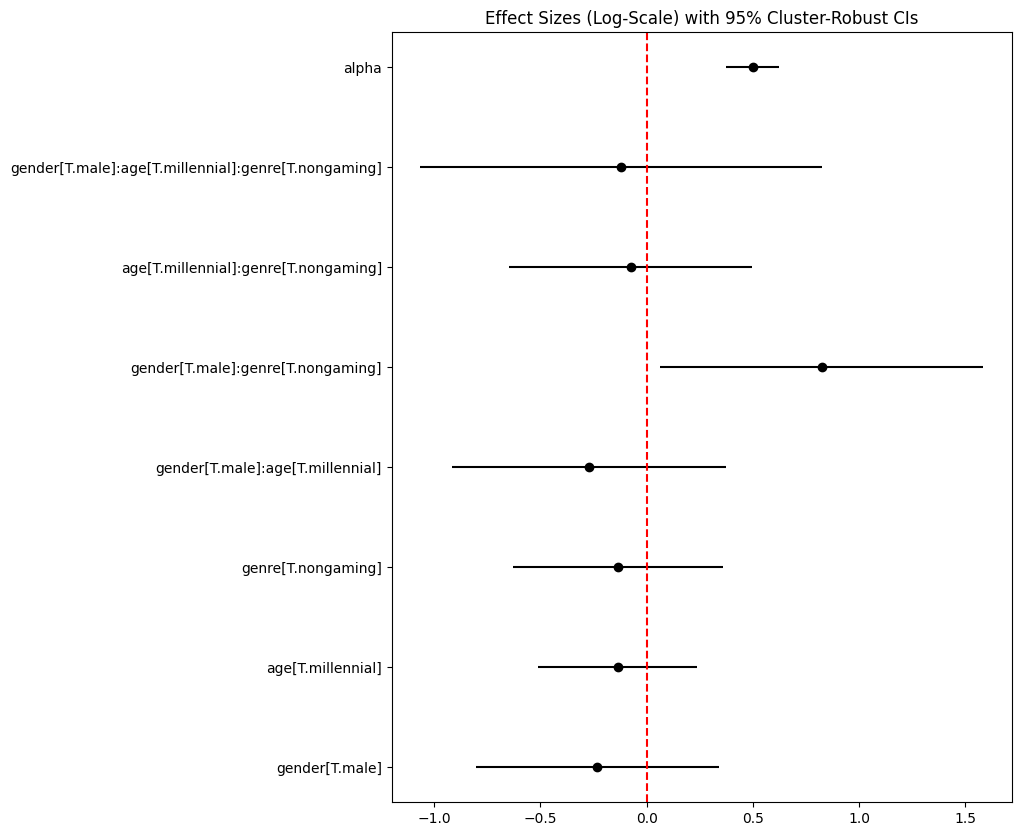

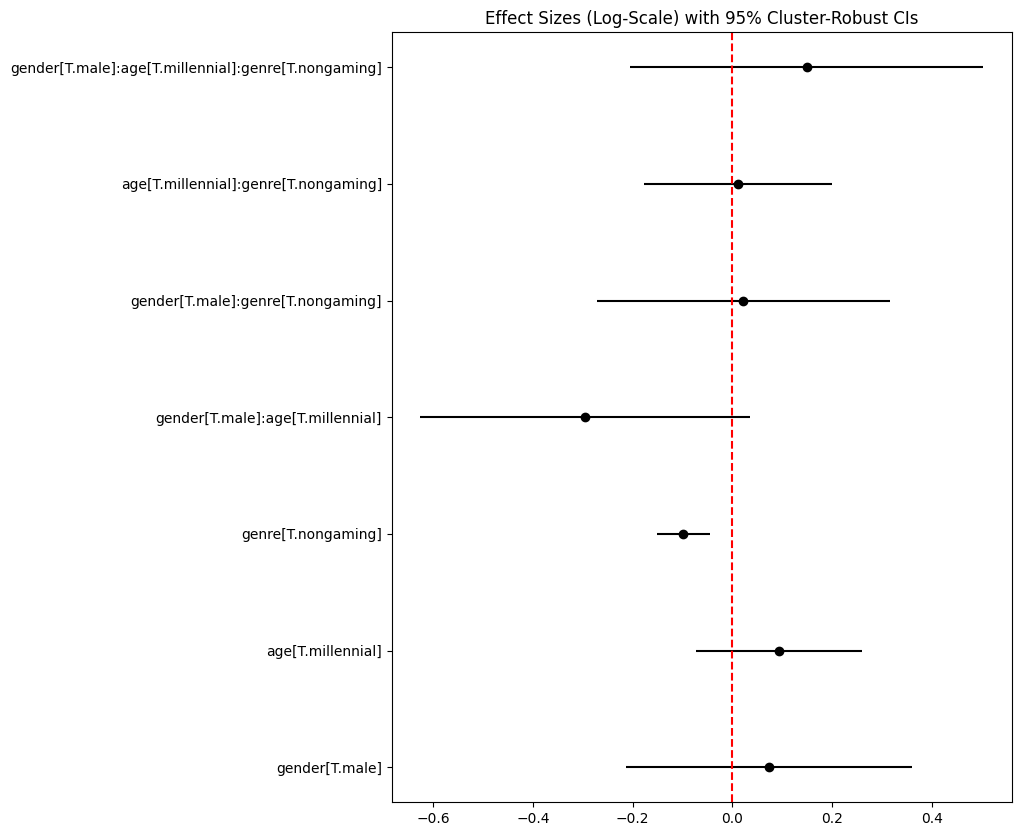

In [23]:
def plot_coefficients(results, name):
    params = results.params[1:] # skip intercept
    conf = results.conf_int().iloc[1:]
    
    plt.figure(figsize=(8, 10))
    for i, (col, val) in enumerate(params.items()):
        plt.errorbar(val, i, xerr=[[val - conf.iloc[i,0]], [conf.iloc[i,1] - val]], fmt='o', color='black')
    
    plt.axvline(0, color='red', linestyle='--')
    plt.yticks(range(len(params)), params.index)
    plt.title("Effect Sizes (Log-Scale) with 95% Cluster-Robust CIs")
    plt.savefig(f'plot_coefficients_{name}.png')
    plt.show()

plot_coefficients(results_total_nb, 'total')
plot_coefficients(results_unique_nb, 'unique')

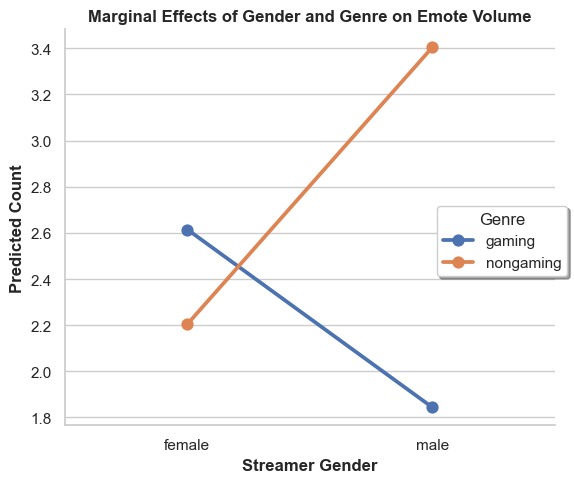

In [18]:
import seaborn as sns

# 1. Create a "grid" of all possible combinations
unique_gender = df['gender'].unique()
unique_age = df['age'].unique()
unique_genre = df['genre'].unique()

grid = pd.MultiIndex.from_product(
    [unique_gender, unique_age, unique_genre], 
    names=['gender', 'age', 'genre']
).to_frame(index=False)

# 2. Get predicted counts (Marginal Means)
grid['predicted_count'] = results_total_nb.predict(grid)

emm = (
    grid.groupby(["gender", "genre"], as_index=False)["predicted_count"]
        .mean()
)

# 3. Create the Facetted Interaction Plot
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=emm, x="gender", y="predicted_count", hue="genre", kind="point", height=5, aspect=0.9
)


# 4. Clean up labels
plt.title("Marginal Effects of Gender and Genre on Emote Volume", fontweight="bold")
plt.xlabel("Streamer Gender", fontweight='bold')
plt.ylabel("Predicted Count", fontweight='bold')
#plt.legend(title="Genre", frameon=True, shadow=True, facecolor='white')

sns.move_legend(
    g, 
    loc="right", 
    title="Genre", 
    frameon=True, 
    shadow=True, 
    facecolor='white'
)

plt.tight_layout()
plt.savefig("plot_gender_genre_total.png", dpi=300)
plt.show()

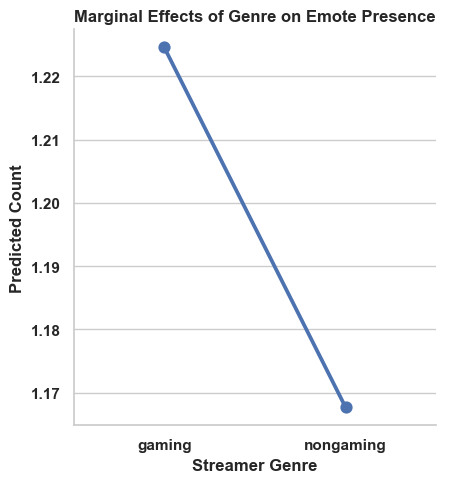

In [11]:
import seaborn as sns

# 1. Create a "grid" of all possible combinations
# This ensures we get predictions for every group in your interaction
unique_gender = df['gender'].unique()
unique_age = df['age'].unique()
unique_genre = df['genre'].unique()

grid = pd.MultiIndex.from_product(
    [unique_gender, unique_age, unique_genre], 
    names=['gender', 'age', 'genre']
).to_frame(index=False)

# 2. Get predicted counts (Marginal Means)
grid['predicted_count'] = results_unique_nb.predict(grid)

emm = (
    grid.groupby(["genre"], as_index=False)["predicted_count"]
        .mean()
)

# 3. Create the Facetted Interaction Plot
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=emm, x="genre", y="predicted_count", kind="point", height=5, aspect=0.9,
)

# 4. Clean up labels
plt.title("Marginal Effects of Genre on Emote Presence", fontweight="bold")
plt.xlabel("Streamer Genre", fontweight='bold')
plt.ylabel("Predicted Count", fontweight='bold')

# Make tick labels bold
ax = plt.gca()

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("plot_genre_unique.png", dpi=500)
plt.show()

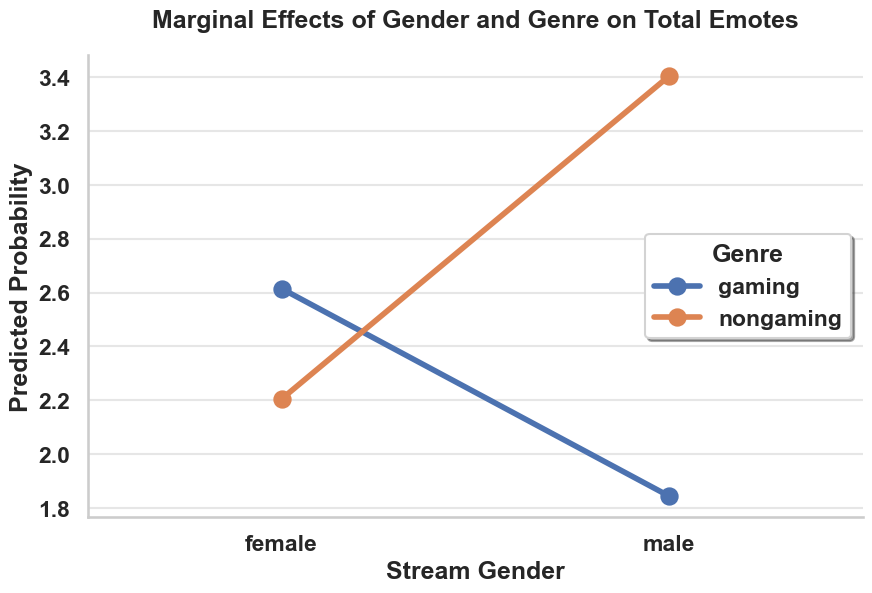

In [22]:
# 1. Create a grid with only Genre
# Note: If your model requires age/gender to run .predict(), 
# you must provide a constant value for them (e.g., the mean or 'Male').
combos = df[['gender', 'genre', 'age']].drop_duplicates()
combos['prob'] = results_total_nb.predict(combos)
    
# Aggregate (mean) across Age to isolate Gender x Genre
plot_data = combos.groupby(['gender', 'genre'])['prob'].mean().reset_index()

# 2. Plotting for "Buttony" Aesthetic
plt.figure(figsize=(10, 6))
sns.set_context("talk") # Makes labels larger/bolder
sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})

# Using a pointplot to show the interaction lines clearly
g = sns.pointplot(
    data=plot_data, 
    x="gender", 
    y="prob", 
    hue="genre",
)

# 3. Clean up the "UI" of the plot
plt.title("Marginal Effects of Gender and Genre on Total Emotes", pad=20, fontweight='bold')
plt.xlabel("Stream Gender", fontweight='bold')
plt.ylabel(f"Predicted Probability", fontweight='bold')

# Make tick labels bold
ax = plt.gca()

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Legend
legend = plt.legend(
    title="Genre",
    frameon=True,
    shadow=True,
    facecolor="white",
    edgecolor="lightgrey", 
    loc="center right"
)

# Make legend text bold
legend.get_title().set_fontweight("bold")
for text in legend.get_texts():
    text.set_fontweight("bold")

# Remove top and right spines for a modern look
sns.despine()

plt.savefig("plot_gender_genre_total.png", dpi=300)
plt.show()

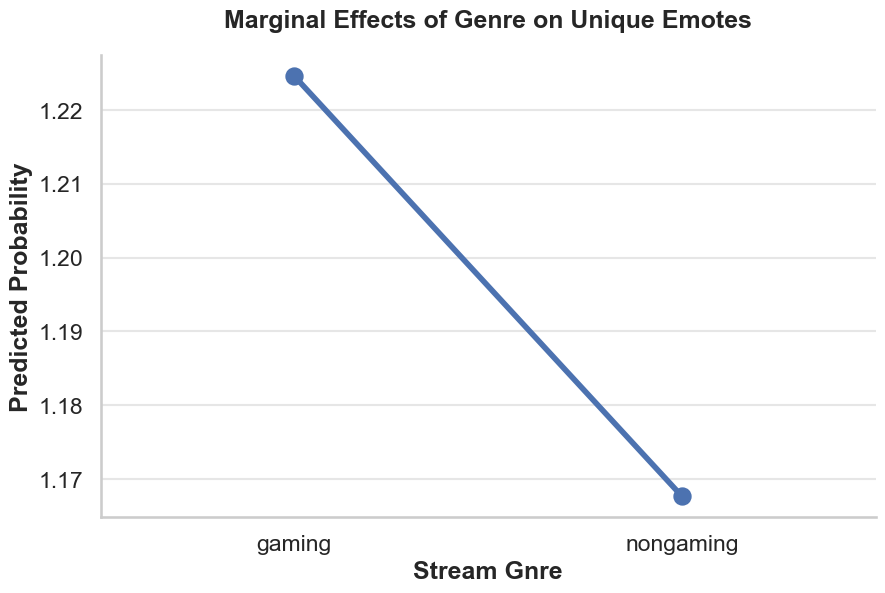

In [16]:
# 1. Create a grid with only Genre
# Note: If your model requires age/gender to run .predict(), 
# you must provide a constant value for them (e.g., the mean or 'Male').
combos = df[['gender', 'genre', 'age']].drop_duplicates()
combos['prob'] = results_unique_nb.predict(combos)
    
# Aggregate (mean) across Age to isolate Gender x Genre
plot_data = combos.groupby('genre')['prob'].mean().reset_index()

# 2. Plotting for "Buttony" Aesthetic
plt.figure(figsize=(10, 6))
sns.set_context("talk") # Makes labels larger/bolder
sns.set_style("whitegrid", {'axes.edgecolor': '.8', 'grid.color': '.9'})

# Using a pointplot to show the interaction lines clearly
g = sns.pointplot(
    data=plot_data, 
    x="genre", 
    y="prob", 
)

# 3. Clean up the "UI" of the plot
plt.title("Marginal Effects of Genre on Unique Emotes", pad=20, fontweight='bold')
plt.xlabel("Stream Gnre", fontweight='bold')
plt.ylabel(f"Predicted Probability", fontweight='bold')
    
# Remove top and right spines for a modern look
sns.despine()
plt.savefig("plot_genre_unique.png", dpi=300)
plt.show()